In [13]:
# Kill any remaining worker processes and reset environment
import multiprocessing
import os
import gc
import torch

# Clean up any lingering processes
if hasattr(multiprocessing, 'get_all_start_methods'):
    multiprocessing.set_start_method('spawn', force=True)

# Force garbage collection
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

print("✓ Environment reset - ready to load data")

✓ Environment reset - ready to load data


In [14]:
import os
from PIL import Image
from torch.utils.data import Dataset

class PainDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        # each folder name is a float label
        for label_name in os.listdir(root_dir):
            label_path = os.path.join(root_dir, label_name)
            if not os.path.isdir(label_path):
                continue

            label_value = float(label_name)  # "0.5" -> 0.5

            for fname in os.listdir(label_path):
                if fname.lower().endswith((".jpg",".jpeg",".png")):
                    self.samples.append((os.path.join(label_path, fname), label_value))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


In [15]:
from torchvision import transforms
import torchvision.transforms as T

# ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.GaussianBlur(5, sigma=(0.1, 2.0)),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


In [16]:
from torch.utils.data import DataLoader

train_ds = PainDataset("../data/raw/img/splitted/train", transform=train_tf)
val_ds   = PainDataset("../data/raw/img/splitted/val", transform=val_tf)
test_ds  = PainDataset("../data/raw/img/splitted/test", transform=val_tf) if os.path.exists("../data/raw/img/splitted/test") else None

# Increased batch size for better gradient estimates
# Note: num_workers=0 for Jupyter notebook compatibility (multiprocessing issues)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=False) if test_ds else None

print(f"Train samples: {len(train_ds)}, Val samples: {len(val_ds)}")
if test_loader:
    print(f"Test samples: {len(test_ds)}")


Train samples: 344, Val samples: 68
Test samples: 91


In [17]:
import torch
import torch.nn as nn
import timm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Use a more powerful backbone (EfficientNet-B2 or ResNet50)
model = timm.create_model("efficientnet_b2", pretrained=True)
# Add dropout for regularization
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.classifier.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 1)
)
model = model.to(device)

# Freeze early layers initially for stable transfer learning
for param in list(model.parameters())[:-20]:
    param.requires_grad = False

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Using device: cpu
Model parameters: 8,061,955
Trainable parameters: 2,748,313
Model parameters: 8,061,955
Trainable parameters: 2,748,313


In [18]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

criterion = nn.SmoothL1Loss()  # More robust than MSE, less sensitive to outliers
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

best_val_loss = float('inf')
patience = 8
patience_counter = 0

def train_one_epoch():
    model.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.float().to(device).unsqueeze(1)

        preds = model(imgs)
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)

def validate():
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            labels = labels.float().to(device).unsqueeze(1)

            preds = model(imgs)
            loss = criterion(preds, labels)
            total_loss += loss.item()
    return total_loss / len(val_loader)

print("Starting training with improved strategy...")
for epoch in range(30):
    tr_loss = train_one_epoch()
    val_loss = validate()
    scheduler.step()
    
    print(f"Epoch {epoch+1:2d}: train={tr_loss:.6f}, val={val_loss:.6f}, lr={optimizer.param_groups[0]['lr']:.2e}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "pain_model_best.pth")
        print(f"  ✓ New best model saved! Val loss: {val_loss:.6f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}. Best val loss: {best_val_loss:.6f}")
            model.load_state_dict(torch.load("pain_model_best.pth", map_location=device))
            break

# Unfreeze all layers for fine-tuning
print("\nUnfreezing all layers for fine-tuning...")
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-7)

for epoch in range(15):
    tr_loss = train_one_epoch()
    val_loss = validate()
    scheduler.step()
    
    print(f"Fine-tune {epoch+1:2d}: train={tr_loss:.6f}, val={val_loss:.6f}, lr={optimizer.param_groups[0]['lr']:.2e}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "pain_model_best.pth")
        print(f"  ✓ Improved best model! Val loss: {val_loss:.6f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Fine-tuning converged at epoch {epoch+1}. Best val loss: {best_val_loss:.6f}")
            model.load_state_dict(torch.load("pain_model_best.pth", map_location=device))
            break

torch.save(model.state_dict(), "pain_model.pth")
print("\n✓ Model training completed and saved!")


Starting training with improved strategy...
Epoch  1: train=2.019148, val=1.865127, lr=9.97e-04
  ✓ New best model saved! Val loss: 1.865127
Epoch  1: train=2.019148, val=1.865127, lr=9.97e-04
  ✓ New best model saved! Val loss: 1.865127
Epoch  2: train=1.437113, val=1.603112, lr=9.89e-04
  ✓ New best model saved! Val loss: 1.603112
Epoch  2: train=1.437113, val=1.603112, lr=9.89e-04
  ✓ New best model saved! Val loss: 1.603112
Epoch  3: train=1.123607, val=0.928248, lr=9.76e-04
  ✓ New best model saved! Val loss: 0.928248
Epoch  3: train=1.123607, val=0.928248, lr=9.76e-04
  ✓ New best model saved! Val loss: 0.928248
Epoch  4: train=1.061850, val=0.818971, lr=9.57e-04
  ✓ New best model saved! Val loss: 0.818971
Epoch  4: train=1.061850, val=0.818971, lr=9.57e-04
  ✓ New best model saved! Val loss: 0.818971
Epoch  5: train=0.999691, val=0.686745, lr=9.33e-04
  ✓ New best model saved! Val loss: 0.686745
Epoch  5: train=0.999691, val=0.686745, lr=9.33e-04
  ✓ New best model saved! Val l

In [19]:
model.load_state_dict(torch.load("pain_model.pth", map_location=device))
model.eval()

# Test on a few samples
print("Sample predictions:")
for i in range(min(5, len(val_ds))):
    img, label = val_ds[i]
    pred = model(img.unsqueeze(0).to(device)).item()
    error = abs(pred - label)
    print(f"  Sample {i+1}: True={label:.2f}, Pred={pred:.2f}, Error={error:.2f}")


Sample predictions:

  Sample 1: True=0.00, Pred=0.01, Error=0.01
  Sample 2: True=0.00, Pred=0.13, Error=0.13
  Sample 3: True=0.00, Pred=0.09, Error=0.09
  Sample 1: True=0.00, Pred=0.01, Error=0.01
  Sample 2: True=0.00, Pred=0.13, Error=0.13
  Sample 3: True=0.00, Pred=0.09, Error=0.09
  Sample 4: True=0.00, Pred=1.98, Error=1.98
  Sample 5: True=0.00, Pred=0.21, Error=0.21
  Sample 4: True=0.00, Pred=1.98, Error=1.98
  Sample 5: True=0.00, Pred=0.21, Error=0.21


In [20]:
import torch
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

def eval_metrics(loader, loader_name="Validation"):
    """Evaluate model with multiple metrics"""
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.float().to(device)
            preds = model(imgs).squeeze(1)

            preds_all.append(preds.cpu().numpy())
            labels_all.append(labels.cpu().numpy())

    preds_all = np.concatenate(preds_all)
    labels_all = np.concatenate(labels_all)
    
    # Clip predictions to valid range [0, 8] if needed
    preds_all = np.clip(preds_all, 0, 8)

    mae = np.mean(np.abs(preds_all - labels_all))
    rmse = np.sqrt(mean_squared_error(labels_all, preds_all))
    r2 = r2_score(labels_all, preds_all)
    mape = mean_absolute_percentage_error(labels_all, preds_all) * 100
    
    print(f"\n{loader_name} Metrics:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape, 'preds': preds_all, 'labels': labels_all}

# Evaluate on validation set
val_metrics = eval_metrics(val_loader, "Validation Set")

# Evaluate on test set if available
if test_loader:
    test_metrics = eval_metrics(test_loader, "Test Set")

print("\n" + "="*50)
print("✓ Model evaluation completed!")



Validation Set Metrics:
  MAE:  0.8566
  RMSE: 1.2867
  R²:   0.7913
  MAPE: 89334514450432000.00%

Test Set Metrics:
  MAE:  0.9543
  RMSE: 1.3502
  R²:   0.7434
  MAPE: 49641775588966400.00%

✓ Model evaluation completed!

Test Set Metrics:
  MAE:  0.9543
  RMSE: 1.3502
  R²:   0.7434
  MAPE: 49641775588966400.00%

✓ Model evaluation completed!


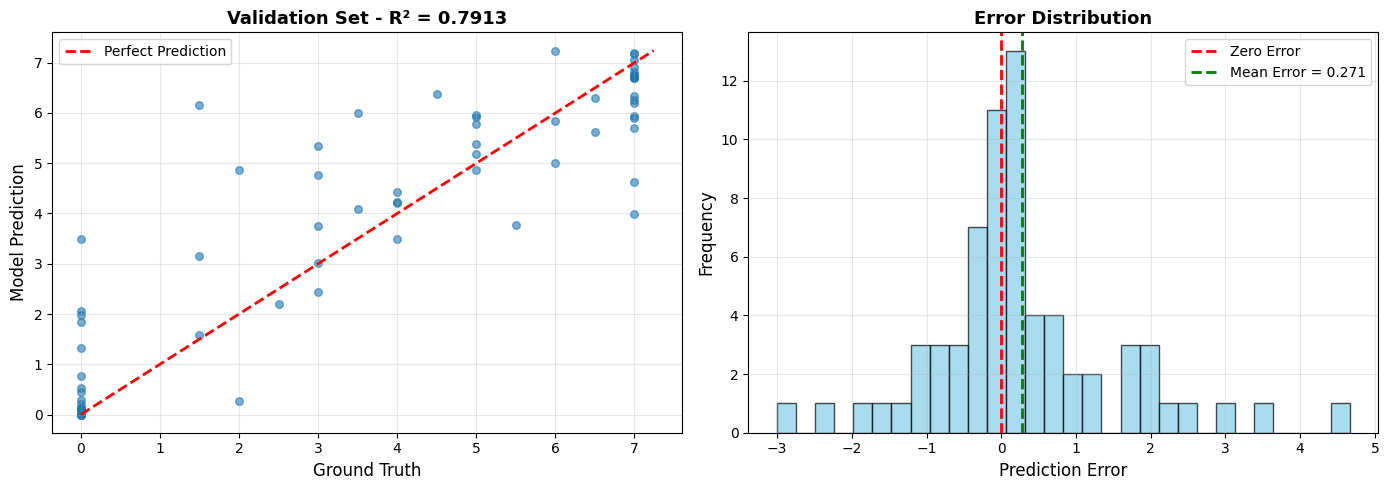

✓ Visualization saved as 'model_evaluation.png'


In [21]:
import matplotlib.pyplot as plt

# Visualize predictions vs ground truth
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(val_metrics['labels'], val_metrics['preds'], alpha=0.6, s=30)
min_val = min(val_metrics['labels'].min(), val_metrics['preds'].min())
max_val = max(val_metrics['labels'].max(), val_metrics['preds'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Ground Truth', fontsize=12)
axes[0].set_ylabel('Model Prediction', fontsize=12)
axes[0].set_title(f'Validation Set - R² = {val_metrics["r2"]:.4f}', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Error distribution
errors = val_metrics['preds'] - val_metrics['labels']
axes[1].hist(errors, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[1].axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
axes[1].axvline(x=errors.mean(), color='g', linestyle='--', lw=2, label=f'Mean Error = {errors.mean():.3f}')
axes[1].set_xlabel('Prediction Error', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Error Distribution', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'model_evaluation.png'")


In [22]:
import numpy as np

def snap_predictions(predictions, valid_steps):
    """
    Snap continuous predictions to the nearest valid discrete step.
    
    Args:
        predictions (np.array or list): Raw continuous model predictions
        valid_steps (list or np.array): Valid discrete step values
    
    Returns:
        np.array: Snapped predictions rounded to nearest valid step
    
    Example:
        >>> predictions = np.array([1.2, 5.3, 0.1, 3.8, 2.1])
        >>> valid_steps = [0, 1.5, 3, 5, 6, 7]
        >>> snapped = snap_predictions(predictions, valid_steps)
        >>> snapped
        array([1.5, 5. , 0. , 3. , 1.5])
    """
    predictions = np.asarray(predictions).flatten()
    valid_steps = np.asarray(valid_steps)
    
    # For each prediction, find the index of the closest valid step
    # This creates a 2D distance matrix: (n_predictions, n_steps)
    distances = np.abs(predictions[:, np.newaxis] - valid_steps[np.newaxis, :])
    
    # Find the index of the minimum distance for each prediction
    closest_indices = np.argmin(distances, axis=1)
    
    # Map indices to actual step values
    snapped = valid_steps[closest_indices]
    
    return snapped


# Test the function with your validation set predictions
valid_steps = [0, 1.5, 3, 5, 6, 7]

print("Testing snap_predictions function:")
print("="*60)

# Apply snapping to validation predictions
val_snapped = snap_predictions(val_metrics['preds'], valid_steps)

# Calculate new metrics with snapped predictions
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_snapped = mean_absolute_error(val_metrics['labels'], val_snapped)
rmse_snapped = np.sqrt(mean_squared_error(val_metrics['labels'], val_snapped))
r2_snapped = r2_score(val_metrics['labels'], val_snapped)

print(f"\nBefore Snapping (Continuous Predictions):")
print(f"  MAE:  {val_metrics['mae']:.4f}")
print(f"  RMSE: {val_metrics['rmse']:.4f}")
print(f"  R²:   {val_metrics['r2']:.4f}")

print(f"\nAfter Snapping (Discrete Predictions):")
print(f"  MAE:  {mae_snapped:.4f}")
print(f"  RMSE: {rmse_snapped:.4f}")
print(f"  R²:   {r2_snapped:.4f}")

improvement_mae = ((val_metrics['mae'] - mae_snapped) / val_metrics['mae']) * 100
improvement_rmse = ((val_metrics['rmse'] - rmse_snapped) / val_metrics['rmse']) * 100
improvement_r2 = ((r2_snapped - val_metrics['r2']) / val_metrics['r2']) * 100

print(f"\nImprovement:")
print(f"  MAE:  {improvement_mae:+.2f}%")
print(f"  RMSE: {improvement_rmse:+.2f}%")
print(f"  R²:   {improvement_r2:+.2f}%")

# Show sample comparisons
print(f"\nSample Predictions Comparison (first 10):")
print(f"{'Ground Truth':<15} {'Raw Pred':<15} {'Snapped':<15} {'Raw Error':<15} {'Snapped Error':<15}")
print("-" * 75)
for i in range(min(10, len(val_metrics['labels']))):
    gt = val_metrics['labels'][i]
    raw = val_metrics['preds'][i]
    snap = val_snapped[i]
    err_raw = abs(raw - gt)
    err_snap = abs(snap - gt)
    print(f"{gt:<15.2f} {raw:<15.2f} {snap:<15.2f} {err_raw:<15.2f} {err_snap:<15.2f}")


Testing snap_predictions function:

Before Snapping (Continuous Predictions):
  MAE:  0.8566
  RMSE: 1.2867
  R²:   0.7913

After Snapping (Discrete Predictions):
  MAE:  0.8309
  RMSE: 1.3131
  R²:   0.7827

Improvement:
  MAE:  +3.00%
  RMSE: -2.05%
  R²:   -1.09%

Sample Predictions Comparison (first 10):
Ground Truth    Raw Pred        Snapped         Raw Error       Snapped Error  
---------------------------------------------------------------------------
0.00            0.01            0.00            0.01            0.00           
0.00            0.13            0.00            0.13            0.00           
0.00            0.09            0.00            0.09            0.00           
0.00            1.98            1.50            1.98            1.50           
0.00            0.21            0.00            0.21            0.00           
0.00            0.00            0.00            0.00            0.00           
0.00            0.09            0.00            0.09  

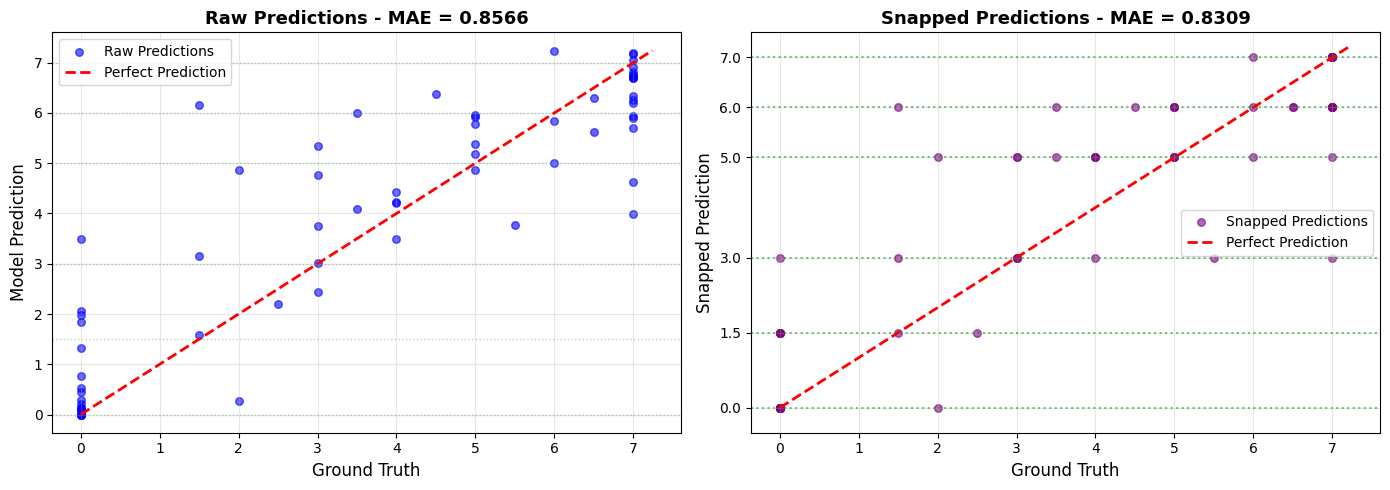

✓ Comparison visualization saved as 'snap_predictions_comparison.png'


In [23]:
# Visualization: Compare raw vs snapped predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Raw predictions
axes[0].scatter(val_metrics['labels'], val_metrics['preds'], alpha=0.6, s=30, color='blue', label='Raw Predictions')
min_val = min(val_metrics['labels'].min(), val_metrics['preds'].min())
max_val = max(val_metrics['labels'].max(), val_metrics['preds'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

# Add valid steps as horizontal grid lines for reference
for step in valid_steps:
    axes[0].axhline(y=step, color='green', linestyle=':', alpha=0.3, linewidth=1)

axes[0].set_xlabel('Ground Truth', fontsize=12)
axes[0].set_ylabel('Model Prediction', fontsize=12)
axes[0].set_title(f'Raw Predictions - MAE = {val_metrics["mae"]:.4f}', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right plot: Snapped predictions
axes[1].scatter(val_metrics['labels'], val_snapped, alpha=0.6, s=30, color='purple', label='Snapped Predictions')
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

# Add valid steps as horizontal grid lines
for step in valid_steps:
    axes[1].axhline(y=step, color='green', linestyle=':', alpha=0.5, linewidth=1.5)

axes[1].set_xlabel('Ground Truth', fontsize=12)
axes[1].set_ylabel('Snapped Prediction', fontsize=12)
axes[1].set_title(f'Snapped Predictions - MAE = {mae_snapped:.4f}', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim(-0.5, 7.5)
axes[1].set_yticks(valid_steps)

plt.tight_layout()
plt.savefig('snap_predictions_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Comparison visualization saved as 'snap_predictions_comparison.png'")
